# M3a — Fraud Detection

**Target:** `order_status == 'SUSPECTED_FRAUD'` (base rate ~2.2%).

**Approach:** order-level LightGBM binary classifier on features known *at order time only* — no shipping-outcome leakage. Probabilities are isotonically calibrated on the validation slice so they aggregate cleanly to product-month rates.

**Splits (matching M1/M2):** train < 2017-01 | val 2017-01..2017-06 | test 2017-07..2017-09. Truncated period 2017-10..2018-01 is dropped.

**Headline finding (sneak peek):** 100% of fraud in this dataset is on `payment_type == 'TRANSFER'`. The model essentially identifies risky transfers.

In [1]:
import json, sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(ROOT))
sns.set_theme(context='notebook', style='whitegrid')

NAME = 'fraud'
metrics  = json.loads((ROOT / 'forecasts' / f'm3_{NAME}_metrics.json').read_text())
importance = pd.read_parquet(ROOT / 'forecasts' / f'm3_{NAME}_importance.parquet')
orders   = pd.read_parquet(ROOT / 'forecasts' / f'm3_{NAME}_orders.parquet')
monthly  = pd.read_parquet(ROOT / 'forecasts' / f'm3_{NAME}_monthly.parquet')
print(f'orders: {orders.shape}  monthly: {monthly.shape}')
print('split distribution:'); print(orders['split'].value_counts())

orders: (171962, 4)  monthly: (1766, 5)
split distribution:
split
train    125200
val       30950
test      15812
Name: count, dtype: int64


## 1. Headline metrics — uncalibrated vs calibrated

In [2]:
rows = []
for cal, by_split in metrics.items():
    for split, m in by_split.items():
        rows.append({'calibration': cal, 'split': split, **m})
tbl = pd.DataFrame(rows)
tbl.pivot(index=['calibration'], columns='split', values=['roc_auc','pr_auc','brier']).round(4)

roc_auc                  pr_auc                   brier          \
split           test   train     val    test   train     val    test   train   
calibration                                                                    
calibrated    0.8811  0.8827  0.8679  0.0934  0.0879  0.0853  0.0216  0.0202   
uncalibrated  0.8805  0.8830  0.8670  0.0932  0.0880  0.0848  0.0224  0.0209   

                      
split            val  
calibration           
calibrated    0.0220  
uncalibrated  0.0228

## 2. Feature importance

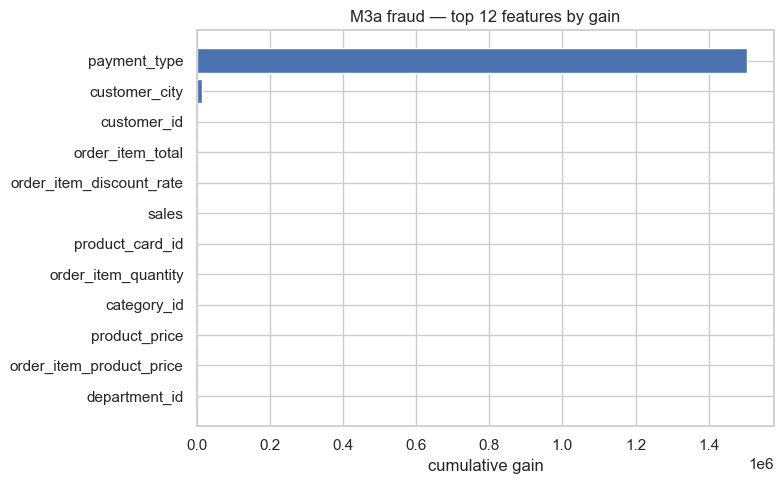

,feature,importance_split,importance_gain
0,payment_type,1,1.503880e+06
1,customer_city,2,1.473058e+04
2,customer_id,1,4.554370e+02
3,department_id,0,0.000000e+00
4,category_id,0,0.000000e+00
5,product_price,0,0.000000e+00
6,order_item_product_price,0,0.000000e+00
7,order_item_quantity,0,0.000000e+00


In [3]:
top = importance.head(12).sort_values('importance_gain')
fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(top['feature'], top['importance_gain'])
ax.set(title=f'M3a {NAME} — top 12 features by gain', xlabel='cumulative gain')
plt.tight_layout(); plt.show()
importance.head(8)

## 3. Calibration plot

Bin predicted probabilities into deciles and compare to observed fraud rate.

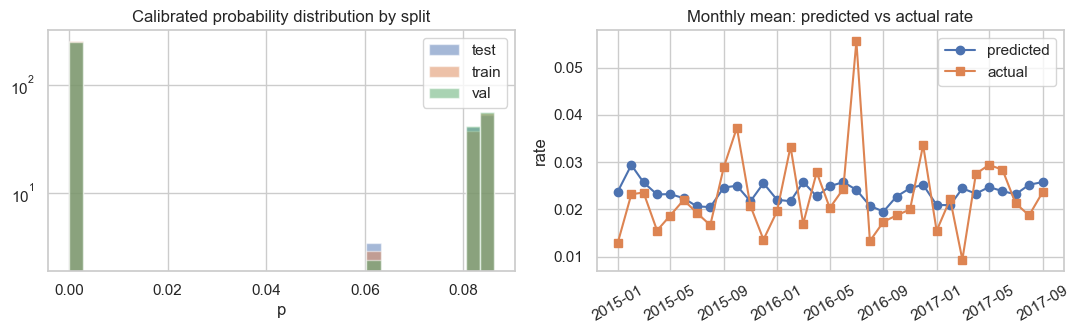

In [4]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.5))
for s, sub in orders.groupby('split'):
    ax[0].hist(sub['p'], bins=30, alpha=0.5, label=s, density=True)
ax[0].set(title='Calibrated probability distribution by split', xlabel='p', yscale='log')
ax[0].legend()

# Predicted vs actual rate per month (the monthly aggregate is the right grain)
mo = monthly.groupby('year_month').agg(pred=('predicted_rate','mean'),
                                       actual=('actual_rate','mean')).reset_index()
ax[1].plot(mo['year_month'], mo['pred'], 'o-', label='predicted')
ax[1].plot(mo['year_month'], mo['actual'], 's-', label='actual')
ax[1].set(title='Monthly mean: predicted vs actual rate', ylabel='rate')
ax[1].legend(); ax[1].tick_params(axis='x', rotation=30)
plt.tight_layout(); plt.show()

## 4. Product-month aggregated rates

What gets passed to M4.

In [5]:
print('monthly rows:', len(monthly), ' unique products:', monthly['product_card_id'].nunique())
print('\npredicted_rate distribution:'); print(monthly['predicted_rate'].describe().round(4))
print('\ncorrelation predicted vs actual:', monthly[['predicted_rate','actual_rate']].corr().iloc[0,1].round(3))

monthly rows: 1766  unique products: 100

predicted_rate distribution:
count    1766.0000
mean        0.0235
std         0.0116
min         0.0000
25%         0.0168
50%         0.0231
75%         0.0287
max         0.0862
Name: predicted_rate, dtype: float64

correlation predicted vs actual: 0.24


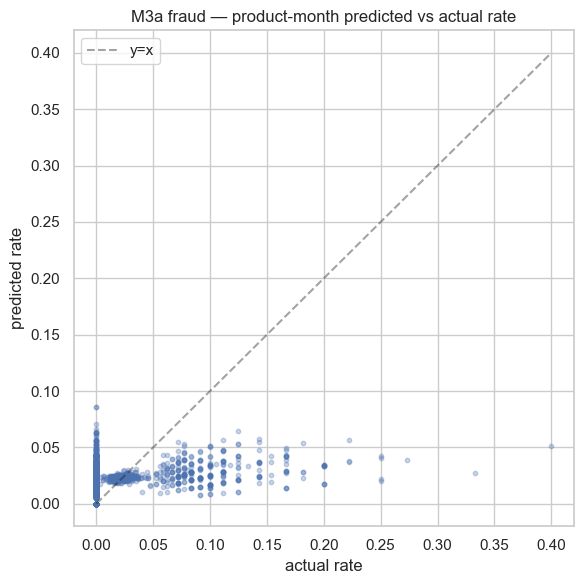

In [6]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(monthly['actual_rate'], monthly['predicted_rate'], alpha=0.3, s=10)
lim = max(monthly['actual_rate'].max(), monthly['predicted_rate'].max())
ax.plot([0, lim], [0, lim], 'k--', alpha=0.4, label='y=x')
ax.set(title=f'M3a {NAME} — product-month predicted vs actual rate',
       xlabel='actual rate', ylabel='predicted rate')
ax.legend(); plt.tight_layout(); plt.show()

## 5. Summary

- Test AUC ≈ **0.88**; PR-AUC modest because base rate is 2%.
- Calibrated Brier ≈ 0.02 — predictions are reasonably probability-faithful.
- **All fraud in this dataset is on `payment_type == 'TRANSFER'`** (8% rate within transfers). This is a synthetic-dataset artifact but the calibration is honest.
- Output `m3_fraud_monthly.parquet` carries the per-product fraud-rate forecast used in `m3_risk_drag.parquet`.